## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[ToUpperCase /@ Alphabet[], Capital];
DefineKind[Alphabet["Greek"], Greek];
DefineKind["b" <> # & /@ Alphabet[], Bar];
DefineKind["d" <> # & /@ Alphabet[], Dot];
DefineKind["h" <> # & /@ Alphabet[], Hat];

## 1. Define Derivative Operators and Metrics

In [8]:
Tdefine[T, "ab"]; Tdefine[F, "-ba"];

In [9]:
SetAttributes[{c1, c2}, Constant]

### 1.1 DerivativeOperatorQ

In [10]:
DerivativeOperatorQ /@ {CD, BD, LD}

{True, False, False}

### 1.2 DefineDerivativeOperator and RemoveDerivativeOperator

공변 도함수를 정의한다. 인자는 공변 도함수 이름, 옵션으로  출력을 위한 문자열, 그리고 공변 도함수가 속한 kind, `TorsionFreeQ`가 있다.

In [11]:
DefineDerivativeOperator[CovD, "D"]

In [12]:
CovD[la, T[lb, lc]]

CovD[la, T[lb, lc]]

In [13]:
TMP`getDerOp[#][CovD] & /@ {Gamma, Ricci, Riemann, Scalar, Weyl}

{GammaCovD, RicciCovD, RiemannCovD, ScalarCovD, WeylCovD}

In [14]:
TMP`getDerOps[Latin]

{CD, CovD}

정의된 공변 도함수의 이름으로 조합된 텐서들이 자동적으로 생성된다:

In [15]:
{GammaCovD[la, lb, uc], RicciCovD[la, lb], 
 RiemannCovD[la, lb, lc, ud], ScalarCovD[],
 WeylCovD[la, lb, lc, ud]}

{GammaCovD[la, lb, uc], RicciCovD[la, lb], RiemannCovD[la, lb, lc, ud], ScalarCovD[], 
 
>   WeylCovD[la, lb, lc, ud]}

In [16]:
TMP`nonTensorList

{GammaCD, GammaCovD}

In [17]:
{RiemannCovD[la, lb, lc, ua], RiemannCovD[la, lb, ub, ua], 
 RicciCovD[la, ua]}

{-RicciCovD[lb, lc], -ScalarCovD[], ScalarCovD[]}

In [18]:
CovD[ua, c1 RicciCovD[la, lb] + c2 F[la, lc] RicciCovD[uc, lb]]

c1 CovD[ua, RicciCovD[la, lb]] + c2 CovD[ua, RicciCovD[uc, lb]] F[la, lc] + 
 
>   c2 CovD[ua, F[la, lc]] RicciCovD[uc, lb]

In [19]:
CovD[la, ub, RicciCovD[lc, ud]]

CovD[la, CovD[ub, RicciCovD[lc, ud]]]

In [20]:
GetSymmetry[GammaCovD]

GenSet[{Cycles[{{1, 2}}], 1}]

In [21]:
GStoString[%]

+ba

`CoordinateBasisQ`는 kind의 성질이다:

In [22]:
{CoordinateBasisQ[Latin], CoordinateBasisQ[Capital]}

{True, False}

In [23]:
DefineDerivativeOperator[CCovD, "D", Capital]

In [24]:
TMP`getDerOp[#][CCovD] & /@ {Gamma, Ricci, Riemann,
                               Scalar, Weyl}

{GammaCCovD, RicciCCovD, RiemannCCovD, ScalarCCovD, WeylCCovD}

In [25]:
GetSymmetry[GammaCCovD]

GenSet[]

TorsionFree가 아닌 공변 도함수를 정의하려면 옵션으로 조정한다:

In [26]:
DefineDerivativeOperator[CovD, "D", TorsionFreeQ -> False]

In [27]:
TorsionFreeQ[CovD]

False

In [28]:
GetSymmetry[GammaCovD]

GenSet[]

In [29]:
GetSymmetry[RiemannCovD]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}]

In [30]:
GStoString[%]

-bacd-abdc

In [31]:
GetSymmetry[RicciCovD]

GenSet[]

In [32]:
DefineDerivativeOperator[CovD, "D", Greek]

In [33]:
TorsionFreeQ[CovD]

True

In [34]:
GetSymmetry[GammaCovD]

GenSet[]

In [35]:
GetSymmetry[RiemannCovD]

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 3}, {2, 4}}], 1}]

In [36]:
GStoString[%]

-bacd-abdc+cdab

In [37]:
GetSymmetry[RicciCovD]  (* "+ba" *)

GenSet[{Cycles[{{1, 2}}], 1}]

In [38]:
CovD[l\[Mu], c1 RicciCovD[l\[Nu], l\[Rho]] + 
            c2 F[l\[Rho], l\[Sigma]] RicciCovD[u\[Sigma], l\[Nu]]]

c1 CovD[lμ, RicciCovD[lν, lρ]] + c2 CovD[lμ, RicciCovD[uσ, lν]] F[lρ, lσ] + 
 
>   c2 CovD[lμ, F[lρ, lσ]] RicciCovD[uσ, lν]

정의된 공변 도함수를 프로그램에서 제거한다:

In [39]:
RemoveDerivativeOperator[CovD]

In [40]:
DerivativeOperatorQ[CovD]

False

In [41]:
GammaCovD[la, lb, lc]

GammaCovD[la, lb, lc]

In [42]:
RemoveDerivativeOperator[CCovD]

프로그램에서 기본적인 공변 도함수인 `CD`는 제거하지 못한다:

In [43]:
RemoveDerivativeOperator[CD]

`1` `2` `3` `4`: Reserved name CD cannot be removed! 

{HeadQs, IndexQs, All, Zero, Latin, Epsilon, Structuref, Torsion, C, D, E, I, N, O, CD, 
 
>   LD, XD, XP, Tscalar, ErrorT, Kdelta, CovDs, Metricg, Gamma, Ricci, Riemann, Scalar, 
 
>   Weyl, GammaCD, RicciCD, RiemannCD, ScalarCD, WeylCD, BD, IP, HodgeStar, CoXD, VD}
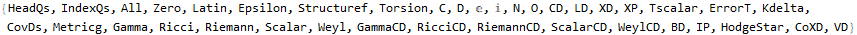

In [44]:
TMP`reservedNameList

### 1.3 MetricQ

In [45]:
MetricQ /@ {Metricg, Phi}

{True, False}

### 1.4 DefineMetric and RemoveMetric

Metric을 정의한다. 인자는 Metric의 이름, 옵션으로 출력을 위한 문자열, Metric이  속한 kind, 대칭 문자열이다.

In [46]:
SetDefaultKind[Capital]

In [47]:
DefineDerivativeOperator[CovD, "D", Latin]

In [48]:
DefineMetric[Phi, "\[CapitalPhi]", Latin]

In [49]:
{GetEpsilon[Latin], GetEpsilon[Capital]}

{EpsilonLatin, Epsilon}

In [50]:
{TMP`getMetricSymmetry[Phi], TMP`getMetricSymmetry[Metricg]}

{1, 1}

In [51]:
{MetricQ[Phi], MetricQ[Metricg]}

{True, True}

In [52]:
{TMP`getCovDs[Phi], TMP`getCovDs[Metricg]}

{{}, {CD}}

In [53]:
{MetricSpaceQ[Latin], MetricSpaceQ[Capital]}

{True, True}

In [54]:
{GetMetric[Latin], GetMetric[Capital]}

{Phi, Metricg}

In [55]:
{EpsilonLatin[la, lb, lc], Epsilon[lA, lB]}

{EpsilonLatin[la, lb, lc], Epsilon[lA, lB]}

In [56]:
{Phi[la, lb], Phi[la, ub], Phi[lA, uB]}

{Phi[la, lb], Kdelta[la, ub], Phi[lA, uB]}

In [57]:
{Metricg[lA, lB], Metricg[lA, uB], Metricg[la, ub]}

{Metricg[lA, lB], Kdelta[lA, uB], Metricg[la, ub]}

In [58]:
{Phi[la, lb], Phi[la, ub], Phi[-1, 2]}

{Phi[la, lb], Kdelta[la, ub], Phi[-1, 2]}

In [59]:
CovD[lc, #] & /@ %

{CovD[lc, Phi[la, lb]], 0, CovD[lc, Phi[-1, 2]]}

In [60]:
{Metricg[lA, lB], Metricg[lA, uB], Metricg[-1, 2]}

{Metricg[lA, lB], Kdelta[lA, uB], Metricg[-1, 2]}

In [61]:
CD[lC, #] & /@ %

{0, 0, CD[lC, Metricg[-1, 2]]}

### 1.5 MakeMetricConnection and ClearMetricConnection

In [62]:
MakeMetricConnection[CovD, Phi]

In [63]:
TMP`getCovDs[Phi]

{CovD}

In [64]:
{Phi[la, lb], Phi[la, ub], Phi[-1, 2]}

{Phi[la, lb], Kdelta[la, ub], Phi[-1, 2]}

In [65]:
CovD[lc, #] & /@ %

{0, 0, CovD[lc, Phi[-1, 2]]}

In [66]:
{CovD[la, Phi[lb, uc]], CovD[-1, Phi[lb, uc]],
 CovD[la, Phi[-1, 2]], CovD[-1, Phi[-1, 2]],
 CovD[la, Phi[-1, -2]], CovD[-1, Phi[-1, -2]]}

{0, 0, CovD[la, Phi[-1, 2]], CovD[-1, Phi[-1, 2]], CovD[la, Phi[-1, -2]], 
 
>   CovD[-1, Phi[-1, -2]]}

In [67]:
CovD[la, #] & /@ {Epsilon[lA, lB], EpsilonLatin[lb, lc, ld]}

{CovD[la, Epsilon[lA, lB]], 0}

In [68]:
CD[lA, #] & /@ {Epsilon[lB, lC], EpsilonLatin[lb, lc]}

{0, CD[lA, EpsilonLatin[lb, lc]]}

In [69]:
ClearMetricConnection[CovD, Phi]

In [70]:
TMP`getCovDs[Phi]

{}

In [71]:
CovD[la, Phi[lb, lc]]

CovD[la, Phi[lb, lc]]

In [72]:
RemoveDerivativeOperator[CovD]

정의된 Metric을 제거한다:

In [73]:
RemoveMetric[Phi]

In [74]:
MetricQ[Phi]

False

In [75]:
SetDefaultKind[Latin]

각각의 kind마다 한 개의 Metric만 허용된다. 특히, DefaultKind인 경우 MetricgFlag이 On이면 프로그램에서 이미 Metricg라는 이름으로 기본 계량 텐서가 정의되었으므로 새로운 Metric을 정의할 수 없다. (DefaultKind의 Metric을 새로 정의하려면 먼저 MetricgFlag을 Off 시켜야 한다.)

In [76]:
DefineMetric[Eps, "\[Epsilon]", Latin]

`1` `2` `3` `4`: Use On[MetricgFlag] or Off[MetricgFlag] to change the metric state of DefaultKind Latin  

In [77]:
Off[MetricgFlag]

In [78]:
DefineMetric[Eps, "\[Epsilon]", Latin, -1]

In [79]:
TMP`getCovDs[Eps]

{}

In [80]:
MakeMetricConnection[CD, Eps]

In [81]:
TMP`getCovDs[Eps]

{CD}

In [82]:
{MetricSpaceQ[Latin], GetMetric[Latin]}

{True, Eps}

In [83]:
{GetEpsilon[Latin], TMP`getMetricSymmetry[Eps], MetricQ[Eps], 
 TMP`getCovDs[Eps]}

{Epsilon, -1, True, {CD}}

In [84]:
{Eps[la, lb], Eps[lc, la], Eps[la, ub]}

{Eps[la, lb], Eps[lc, la], Kdelta[la, ub]}

In [85]:
TMP`getGenSetOf[Eps[la, lb]]

GenSet[{Cycles[{{1, 2}}], -1}]

In [86]:
TMP`getGenSetOf[Kdelta[la, ub]]  (* Kdelta is anti-symmetric! *)

GenSet[{Cycles[{{1, 2}}], -1}]

In [87]:
RemoveMetric[Eps]

In [88]:
On[MetricgFlag]

In [89]:
{MetricSpaceQ[Latin], GetMetric[Latin]}

{True, Metricg}

In [90]:
{GetEpsilon[Latin], TMP`getMetricSymmetry[Metricg],
 MetricQ[Metricg], TMP`getCovDs[Metricg]}

{Epsilon, 1, True, {CD}}

### 1.6 MetricSpaceQ and MetricOf

In [91]:
MetricSpaceQ /@ TMP`definedKindList

{False, True, False, False, False, False, False}

In [92]:
GetMetric /@ TMP`definedKindList

{Null, Metricg, Null, Null, Null, Null, Null}

### 1.7 GetEpsilon

In [93]:
GetEpsilon /@ TMP`definedKindList

{Null, Epsilon, EpsilonCapital, EpsilonGreek, EpsilonBar, EpsilonDot, EpsilonHat}

### 1.8 covariantNameQ

In [94]:
TMP`covariantNameQ[#, Metricg] & /@ {CD, BD, LD}

{True, False, False}

In [95]:
TMP`covariantNameQ[#, Metricg,
                    {CovDs -> {BD, LD}}] & /@ {CD, BD, LD}

{True, True, True}

In [96]:
TMP`covariantNameQ[#, la] & /@ {CD, BD, LD}

{True, False, False}

In [97]:
TMP`covariantNameQ[#, la, {CovDs -> {BD, LD}}] & /@ {CD, BD, LD}

{True, True, True}

In [98]:
TMP`getCovDs[Metricg] = {CD, BD, LD};

In [99]:
TMP`covariantNameQ[#, Metricg] & /@ {CD, BD, LD}

{True, True, True}

In [100]:
TMP`covariantNameQ[#, la] & /@ {CD, BD, LD}

{True, True, True}

In [101]:
TMP`getCovDs[Metricg] = {CD};  (* default *)

In [102]:
TMP`covariantNameQ[#, Metricg] & /@ {CD, BD, LD}

{True, False, False}

In [103]:
TMP`covariantNameQ[#, la] & /@ {CD, BD, LD}

{True, False, False}

## 2. Pre-defined Tensors

### 2.1 Kdelta

In [8]:
(* for no metric or symmetric metric *)
TMP`getGenSetOf[Kdelta[la, ub]]

GenSet[{Cycles[{{1, 2}}], 1}]

`Kdelta`는 dn-up 또는 up-dn인 경우만 의미가 있다:

In [10]:
{Kdelta[la, lb], Kdelta[la, ub], Kdelta[ua, lb], Kdelta[ua, ub]}

{Kdelta[la, lb], Kdelta[la, ub], Kdelta[ua, lb], Kdelta[ua, ub]}

In [11]:
% // SyntaxCheck

`1` `2` `3` `4`: Kdelta has wrong-dn/up: {la, lb}  

`1` `2` `3` `4`: Kdelta has wrong-dn/up: {ua, ub}  

{ErrorT[Kdelta][la, lb], Kdelta[la, ub], Kdelta[ua, lb], ErrorT[Kdelta][ua, ub]}

In [12]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [13]:
GetSymmetry[Eps]

GenSet[{Cycles[{{1, 2}}], -1}]

In [14]:
TMP`getGenSetOf[Kdelta[lA, uB]]  (* for antisymmetric metric *)

GenSet[{Cycles[{{1, 2}}], -1}]

Kdelta[-1, 1]   0               0

0               Kdelta[-2, 2]   0

0               0               Kdelta[-3, 3]
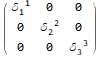

In [15]:
Table[Kdelta[-i, j], {i, 3}, {j, 3}] // MatrixForm

Kdelta[1, -1]   0               0

0               Kdelta[2, -2]   0

0               0               Kdelta[3, -3]
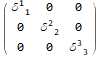

In [16]:
Table[Kdelta[i, -j], {i, 3}, {j, 3}] // MatrixForm

### 2.2 Epsilon, Torsion and Structure constants

In [113]:
{Epsilon[la, lb], EpsilonGreek[l\[Mu], l\[Nu]], 
 EpsilonCapital[lA, lB], EpsilonBar[lba, lbb],
 EpsilonDot[lda, ldb], EpsilonHat[lha, lhb]}

{Epsilon[la, lb], EpsilonGreek[lμ, lν], EpsilonCapital[lA, lB], EpsilonBar[lba, lbb], 
 
>   EpsilonDot[lda, ldb], EpsilonHat[lha, lhb]}

In [114]:
{Torsion[la, lb, uc], TorsionGreek[l\[Mu], l\[Nu], u\[Rho]], 
 TorsionCapital[lA, lB, uC], TorsionBar[lba, lbb, ubc], 
 TorsionDot[lda, ldb, udc], TorsionHat[lha, lhb, uhc]}

{Torsion[la, lb, uc], TorsionGreek[lμ, lν, uρ], TorsionCapital[lA, lB, uC], 
 
>   TorsionBar[lba, lbb, ubc], TorsionDot[lda, ldb, udc], TorsionHat[lha, lhb, uhc]}

In [115]:
{Structuref[la, lb, lc],
 StructurefGreek[l\[Mu], l\[Nu], l\[Rho]], 
 StructurefCapital[lA, lB, lC], StructurefBar[lba, lbb, lbc], 
 StructurefDot[lda, ldb, ldc], StructurefHat[lha, lhb, lhc]}

{Structuref[la, lb, lc], StructurefGreek[lμ, lν, lρ], StructurefCapital[lA, lB, lC], 
 
>   StructurefBar[lba, lbb, lbc], StructurefDot[lda, ldb, ldc], 
 
>   StructurefHat[lha, lhb, lhc]}

In [116]:
Off[CoordinateBasisFlag[Latin]]

In [117]:
Structuref[la, lb, uc]

Structuref[la, lb, uc]

In [118]:
On[CoordinateBasisFlag[Latin]]

In [119]:
Structuref[la, lb, uc]

Structuref[la, lb, uc]

### 2.3 Epsilon and Metricg

In [120]:
{Metricg[la, lb], Epsilon[la, lb, lc, ld]}

{Metricg[la, lb], Epsilon[la, lb, lc, ld]}

Epsilon 텐서는 Dimension 크기의 rank를 갖는 반대칭 텐서이다:

In [121]:
{Epsilon[], Epsilon[la], Epsilon[lb, la], Epsilon[la, lc, lb], 
 Epsilon[lb, la, ld, lc]}

{Epsilon[], Epsilon[la], Epsilon[lb, la], Epsilon[la, lc, lb], Epsilon[lb, la, ld, lc]}

In [122]:
SetDimension[3]

In [123]:
{Epsilon[], Epsilon[la], Epsilon[lb, la], Epsilon[la, lc, lb], 
  Epsilon[lb, la, ld, lc]} // SyntaxCheck

`1` `2` `3` `4`: invalid number of indices for Epsilon  

`1` `2` `3` `4`: invalid number of indices 3 for Epsilon

`1` `2` `3` `4`: invalid number of indices 3 for Epsilon

Further output of `1` will be suppressed during this calculation.: Further output of Msg::err will be suppressed during this calculation.

{ErrorT[Epsilon][], ErrorT[Epsilon][la], ErrorT[Epsilon][lb, la], Epsilon[la, lc, lb], 
 
>   ErrorT[Epsilon][lb, la, ld, lc]}

In [124]:
ClearDimension[]

Metric 텐서의 Tensorial 인덱스가 dn-up 또는 up-dn이면 기본적으로 Kronecker Delta 텐서 역할을 한다.

In [125]:
{Metricg[la, lb], Metricg[ua, lb], Metricg[-1, 2]}

{Metricg[la, lb], Kdelta[ua, lb], Metricg[-1, 2]}

### 2.4 CD-related Tensors

In [126]:
{GammaCD[la, lb, uc], RicciCD[la, lb],
 RiemannCD[la, lb, lc, ud], ScalarCD[], WeylCD[la, lb, lc, ud]}

{GammaCD[la, lb, uc], RicciCD[la, lb], RiemannCD[la, lb, lc, ud], ScalarCD[], 
 
>   WeylCD[la, lb, lc, ud]}

### 2.5 SetDefaultKind

`SetDefaultKind`는 `DefaultKind`를 결정한다. 공변 연산자 `CD`와 계량 텐서 `Metricg`, `Epsilon`은 항상 `DefaultKind`에 속한다.

In [127]:
DefaultKind

Latin

In [128]:
TMP`getDerOps[DefaultKind]

{CD}

In [129]:
{MetricSpaceQ[DefaultKind], GetMetric[DefaultKind]}

{True, Metricg}

In [130]:
{GetEpsilon[Latin], TMP`getMetricSymmetry[Metricg],
 MetricQ[Metricg], TMP`getCovDs[Metricg]}

{Epsilon, 1, True, {CD}}

In [131]:
{Metricg[ua, lb], Metricg[lA, uB]}

{Kdelta[ua, lb], Metricg[lA, uB]}

In [132]:
CD[lc, #] & /@ {Metricg[la, lb], Metricg[lA, lB]}

{0, CD[lc, Metricg[lA, lB]]}

In [133]:
CD[lc, #] & /@ {Epsilon[la, lb], Epsilon[lA, lB]}

{0, CD[lc, Epsilon[lA, lB]]}

In [134]:
SetDimension[3]

In [135]:
CD[lf, #] & /@ {Epsilon[la, lb], Epsilon[la, lb, lc],
                 Epsilon[la, lb, lc, ld]}

{CD[lf, Epsilon[la, lb]], 0, CD[lf, Epsilon[la, lb, lc, ld]]}

In [136]:
ClearDimension[]

#### 2.5.1 Spacetime

In [137]:
SetDefaultKind[Greek]

In [138]:
DefaultKind

Greek

In [139]:
TMP`getDerOps[DefaultKind]

{CD}

In [140]:
GetMetric[DefaultKind]

Metricg

In [141]:
GetEpsilon[Greek]

Epsilon

In [142]:
{Metricg[la, ub], Metricg[u\[Mu], l\[Nu]]}

{Metricg[la, ub], Kdelta[uμ, lν]}

In [143]:
{KindOf[Metricg], KindOf[CD]}

{Greek, Greek}

In [144]:
{CD[la, Metricg[lb, lc]], CD[l\[Rho], Metricg[l\[Mu], l\[Nu]]]}

{CD[la, Metricg[lb, lc]], 0}

In [145]:
{CD[la, Epsilon[lb, lc]], CD[l\[Mu], Epsilon[lb, lc]], 
 CD[la, Epsilon[l\[Mu], l\[Nu]]], 
 CD[l\[Rho], Epsilon[l\[Mu], l\[Nu]]]}

{CD[la, Epsilon[lb, lc]], CD[lμ, Epsilon[lb, lc]], CD[la, Epsilon[lμ, lν]], 0}

#### 2.5.2 Default

In [146]:
SetDefaultKind[Latin]

In [147]:
DefaultKind

Latin

In [148]:
TMP`getDerOps[DefaultKind]

{CD}

In [149]:
GetMetric[DefaultKind]

Metricg

In [150]:
GetEpsilon[DefaultKind]

Epsilon

### 2.6 Set and Clear Dimension, Signature

시공간의 차원값을 설정한다.

In [151]:
SetDimension[4]

In [152]:
GetDimension[DefaultKind]

4

시공간의 Signature를 설정한다.

In [153]:
SetSignature[-1]

In [154]:
GetSignature[DefaultKind]

-1

시공간의 차원값, Signature를 삭제한다.

In [155]:
ClearDimension[]

In [156]:
GetDimension[DefaultKind]

GetDimension[Latin]

In [157]:
ClearSignature[]

In [158]:
GetSignature[DefaultKind]

GetSignature[Latin]

### 2.7 Set and Clear Coordinates

In [159]:
coSys = {t, x, y, z};

In [160]:
SetCoordinates[coSys]

In [161]:
ClearCoordinates[]

Non-coordinate Basis:

In [162]:
Off[CoordinateBasisFlag]

In [163]:
coSys = {t, x};
basisM = {{E^-\[Rho][t, x], 0}, {0, E^-\[Rho][t, x]}}

-ρ[t, x]           -ρ[t, x]
{{E        , 0}, {0, E        }}

In [165]:
SetCoordinates[coSys, basisM]

In [166]:
ClearCoordinates[]

In [167]:
On[CoordinateBasisFlag]  (* default *)

### 2.8 Status

In [168]:
SetDimension[4]

프로그램의 옵션과 전역변수의 값을 표시해 준다.

AutoFlag             True

MarkErrorFlag        True

ResetDummiesFlag     True

SyntaxCheckFlag      False

EvaluateBDFlag       False

KdeltaFlag           True

MetricgFlag          True

InitCTensorFlag      False

TorsionFreeQ of CD   True

----------           -----

Kind                 Latin

Dimension            4

Signature            Any

Coordinates          none

CoordinateBasisQ     True
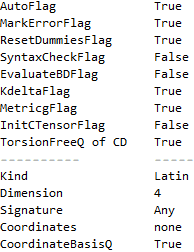

In [169]:
Status[]

In [170]:
SetSignature[-1]

AutoFlag             True

MarkErrorFlag        True

ResetDummiesFlag     True

SyntaxCheckFlag      False

EvaluateBDFlag       False

KdeltaFlag           True

MetricgFlag          True

InitCTensorFlag      False

TorsionFreeQ of CD   True

----------           -----

Kind                 Latin

Dimension            4

Signature            -1

Coordinates          none

CoordinateBasisQ     True
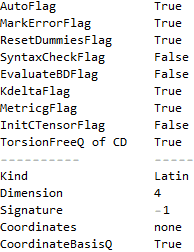

In [171]:
Status[]

In [172]:
ClearDimension[]

AutoFlag             True

MarkErrorFlag        True

ResetDummiesFlag     True

SyntaxCheckFlag      False

EvaluateBDFlag       False

KdeltaFlag           True

MetricgFlag          True

InitCTensorFlag      False

TorsionFreeQ of CD   True

----------           -----

Kind                 Latin

Dimension            Any

Signature            -1

Coordinates          none

CoordinateBasisQ     True
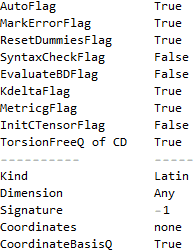

In [173]:
Status[]

좌표계와 그에 따른 Dimension을 설정한다.

In [174]:
SetCoordinates[{t, r, \[Theta], \[Phi]}]

AutoFlag             True

MarkErrorFlag        True

ResetDummiesFlag     True

SyntaxCheckFlag      False

EvaluateBDFlag       False

KdeltaFlag           True

MetricgFlag          True

InitCTensorFlag      False

TorsionFreeQ of CD   True

----------           -----

Kind                 Latin

Dimension            4

Signature            -1

                     t
                     r
                     θ
Coordinates          ϕ

CoordinateBasisQ     True
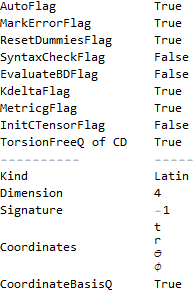

In [175]:
Status[]

설정된 좌표계와 Dimension의 값을 제거한다.

In [176]:
ClearCoordinates[]

AutoFlag             True

MarkErrorFlag        True

ResetDummiesFlag     True

SyntaxCheckFlag      False

EvaluateBDFlag       False

KdeltaFlag           True

MetricgFlag          True

InitCTensorFlag      False

TorsionFreeQ of CD   True

----------           -----

Kind                 Latin

Dimension            Any

Signature            -1

Coordinates          none

CoordinateBasisQ     True
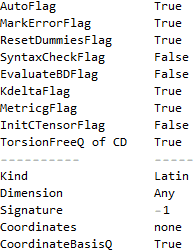

In [177]:
Status[]

Kind에 따른 정보를 보여준다:

Kind               Greek

Dimension          Any

Signature          Any

Coordinates        none

CoordinateBasisQ   False
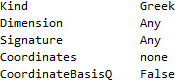

In [178]:
Status[Greek]

In [182]:
SetDimension[2, Greek]

Kind               Greek

Dimension          Any

Signature          Any

Coordinates        none

CoordinateBasisQ   False
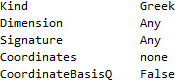

In [179]:
Status[Greek]

In [184]:
ClearDimension[Greek]

Kind               Greek

Dimension          Any

Signature          Any

Coordinates        none

CoordinateBasisQ   False
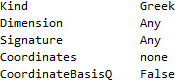

In [180]:
Status[Greek]

## 3. Pre-defined Tensorial Operators

In [181]:
Tdefine[f[]]; Tdefine[v[ua], "a"];
Tdefine[T, "ab"]; Tdefine[F, "-ba"]

In [183]:
SetAttributes[{c1, c2}, Constant]

### 3.1 BD: Ordinary Derivative

CD type의 ordinary derivative 연산자이다.

In [184]:
BD[1, v[lb]]  (* CoordinateBasisQ[DefaultKind] = True *)

BD[1, v[lb]]

In [185]:
BD[la, v[lb]]

BD[la, v[lb]]

In [186]:
BD[uA, v[lb]]  (* CoordinateBasisQ[Capital] = False *)

BD[uA, v[lb]]

선형 미분연산자이다.

In [187]:
BD[ua, c1 RicciCD[la, lb] + c2 F[la, lc] RicciCD[uc, lb]]

c1 BD[ua, RicciCD[la, lb]] + c2 BD[ua, RicciCD[uc, lb]] F[la, lc] + 
 
>   c2 BD[ua, F[la, lc]] RicciCD[uc, lb]

Contraction과 교환된다.

In [188]:
{BD[la, Metricg[lb, uc]], BD[la, Metricg[lb, lc]]}

{0, BD[la, Metricg[lb, lc]]}

`IndexedObject`의 `Log`나 `Power`:

BD[la, f[]]                      f[]
{-----------, 2 BD[la, f[]] f[], E    BD[la, f[]], 
     f[]
 
     -1 + f[]                  f[]
>   x         BD[la, x] f[] + x    BD[la, f[]] Log[x]}
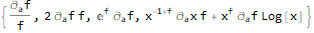

In [189]:
{BD[la, Log[f[]]], BD[la, f[]^2], BD[la, E^f[]], BD[la, x^f[]]}

In [190]:
BD[lc, (RicciCD[la, lb] Metricg[ua, ub])^n]

-1 + n
n BD[lc, RicciCD[la, lb]] Metricg[ua, ub] (Metricg[ua, ub] RicciCD[la, lb])       + 
 
                                                                               -1 + n
>   n BD[lc, Metricg[ua, ub]] RicciCD[la, lb] (Metricg[ua, ub] RicciCD[la, lb])       + 
 
                                                                                        n
>   BD[lc, n] Log[Metricg[u$3, u$4] RicciCD[l$3, l$4]] (Metricg[ua, ub] RicciCD[la, lb])

In [191]:
BD[lc, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]^n]

n BD[lc, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             -1 + n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]       + 
 
>   BD[lc, n] Log[Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]

연속한 미분은 인자를 연속해서 쓰면 된다.

In [192]:
Off[CoordinateBasisFlag]

In [193]:
{BD[lb, la, F[ua, ub]], BD[lb, la, RicciCD[ua, ub]]}

{BD[lb, BD[la, F[ua, ub]]], BD[lb, BD[la, RicciCD[ua, ub]]]}

In [194]:
On[CoordinateBasisFlag]

In [195]:
{BD[lb, la, F[ua, ub]], BD[lb, la, RicciCD[ua, ub]]}

{BD[lb, BD[la, F[ua, ub]]], BD[lb, BD[la, RicciCD[ua, ub]]]}

`SyntaxCheckFlag`이 Off이면 오류 메세지가 발생하지 않는다.

In [196]:
BD[aa, RiemannCD[la, ub, ua, ud]]  (* no SyntaxCheck *)

BD[aa, RicciCD[ub, ud]]

In [197]:
BD[aa, RiemannCD[la, ub, ua, ud]] // SyntaxCheck

`1` is not a valid `2`.: aa is not a valid index.

ErrorT[BD][aa, RicciCD[ub, ud]]

BD는 모든 종류의 Kind에서 사용할 수 있다.

In [198]:
Tdefine[CF[uA, uB]]

In [199]:
{BD[lB, lA, CF[uA, uB]], BD[lb, la, F[ua, ub]],
 BD[-1, la, F[ua, 1]], BD[ub, la, F[ua, lb]]} // SyntaxCheck

{BD[lB, BD[lA, CF[uA, uB]]], BD[lb, BD[la, F[ua, ub]]], BD[-1, BD[la, F[ua, 1]]], 
 
>   BD[ub, BD[la, F[ua, lb]]]}

In [200]:
{BD[lB, lA, F[la, lb]], BD[l\[Mu], l\[Nu], F[la, lb]], 
  BD[-1, lA, F[la, -1]]} // SyntaxCheck

{BD[lB, BD[lA, F[la, lb]]], BD[lμ, BD[lν, F[la, lb]]], BD[-1, BD[lA, F[la, -1]]]}

### 3.2 CD: Covariant Derivative

CD type의 `Metricg`에 대한 covariant derivative 연산자이다.

In [201]:
{CD[la, v[ua]], CD[1, v[la]], CD[-1, v[1]]}

{CD[la, v[ua]], CD[1, v[la]], CD[-1, v[1]]}

In [202]:
{CD[la, Metricg[lb, lc]], CD[la, Epsilon[lb, lc, ld, le]], 
 CD[la, Metricg[-1, lc]]}

{0, 0, CD[la, Metricg[-1, lc]]}

In [203]:
CD[la, RiemannCD[ua, lb, lc, ld] Metricg[ub, uc]]

CD[la, RiemannCD[ua, lb, lc, ld]] Metricg[ub, uc]

선형 연산자이다.

In [204]:
CD[ua, c1 RicciCD[la, lb] + c2 F[la, lc] RicciCD[uc, lb]]

c1 CD[ua, RicciCD[la, lb]] + c2 CD[ua, RicciCD[uc, lb]] F[la, lc] + 
 
>   c2 CD[ua, F[la, lc]] RicciCD[uc, lb]

Contraction과 교환된다.

In [205]:
{CD[la, Metricg[lb, uc]], CD[la, Metricg[-1, lc]]}

{0, CD[la, Metricg[-1, lc]]}

`IndexedObject`의 `Log`나 `Power`:

CD[la, f[]]                      f[]
{-----------, 2 CD[la, f[]] f[], E    CD[la, f[]], 
     f[]
 
     -1 + f[]                  f[]
>   x         CD[la, x] f[] + x    CD[la, f[]] Log[x]}
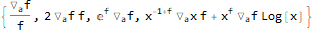

In [206]:
{CD[la, Log[f[]]], CD[la, f[]^2], CD[la, E^f[]], CD[la, x^f[]]}

In [207]:
CD[lc, (RicciCD[la, lb] Metricg[ua, ub])^n]

-1 + n
n CD[lc, RicciCD[la, lb]] Metricg[ua, ub] (Metricg[ua, ub] RicciCD[la, lb])       + 
 
                                                                                        n
>   CD[lc, n] Log[Metricg[u$7, u$8] RicciCD[l$7, l$8]] (Metricg[ua, ub] RicciCD[la, lb])

In [208]:
CD[lc, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]^n]

n CD[lc, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             -1 + n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]       + 
 
>   CD[lc, n] Log[Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]

연속한 미분은 인자를 연속해서 쓰면 된다.

In [209]:
CD[la, lb, lc, F[ld, le]]

CD[la, CD[lb, CD[lc, F[ld, le]]]]

In [210]:
CD[lb, la, f[]]

CD[lb, CD[la, f[]]]

DefaultKind의 인덱스에 작용한다:

In [211]:
SetDefaultKind[Capital]

In [212]:
{CD[lA, Metricg[lB, lC]], CD[la, Metricg[lB, lC]], 
 CD[lA, Metricg[l\[Mu], lB]]}

{0, CD[la, Metricg[lB, lC]], CD[lA, Metricg[lμ, lB]]}

In [213]:
SetDefaultKind[Latin]  (* default *)

### 3.3 LD: Lie Derivative

LD type의 Lie derivative 연산자이다.

In [214]:
{LD[v, v[la]], LD[v, v[ua]], LD[v, v[1]]}

{LD[v, v[la]], 0, LD[v, v[1]]}

In [215]:
LD[v, RiemannCD[la, lb, ub, uc]]

-LD[v, RicciCD[la, uc]]

선형 연산자이다.

In [216]:
LD[v, c1 RicciCD[la, lb] + c2 F[la, lc] RicciCD[uc, lb]]

c1 LD[v, RicciCD[la, lb]] + c2 F[la, lc] LD[v, RicciCD[uc, lb]] + 
 
>   c2 LD[v, F[la, lc]] RicciCD[uc, lb]

Contraction과 교환된다.

In [217]:
{LD[v, Metricg[lb, uc]], LD[v, Metricg[lb, lc]]}

{0, LD[v, Metricg[lb, lc]]}

`IndexedObject`의 `Log`나 `Power`:

LD[v, f[]]                     f[]
{----------, 2 f[] LD[v, f[]], E    LD[v, f[]], 
    f[]
 
     -1 + f[]                 f[]
>   x         f[] LD[v, x] + x    LD[v, f[]] Log[x]}
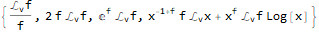

In [218]:
{LD[v, Log[f[]]], LD[v, f[]^2], LD[v, E^f[]], LD[v, x^f[]]}

In [219]:
LD[v, (RicciCD[la, lb] Metricg[ua, ub])^n]

-1 + n
n LD[v, RicciCD[la, lb]] Metricg[ua, ub] (Metricg[ua, ub] RicciCD[la, lb])       + 
 
                                                                              -1 + n
>   n LD[v, Metricg[ua, ub]] RicciCD[la, lb] (Metricg[ua, ub] RicciCD[la, lb])       + 
 
>   LD[v, n] Log[Metricg[u$11, u$12] RicciCD[l$11, l$12]] 
 
                                      n
>    (Metricg[ua, ub] RicciCD[la, lb])

In [220]:
LD[v, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]^n]

n LD[v, Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             -1 + n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]       + 
 
>   LD[v, n] Log[Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]] 
 
                                             n
>    Tscalar[RicciCD[la, lb] RicciCD[ua, ub]]

LD의 Kind는 첫 번째 인자인 벡터의 Kind로 해석한다.

In [221]:
{LD[v, v[lA]], LD[v, v[uA]], LD[v, v[ua]]}

{LD[v, v[lA]], LD[v, v[uA]], 0}

### 3.4 KindOf

In [222]:
DefaultKind = Capital;

In [223]:
TMP`defineOperand[T, "T", "ab", {Latin, Greek}, {-1}];
TMP`defineOperator[CovD, "D", CD]

#### 3.4.1 Kdelta

In [225]:
{KindOf[Kdelta[la, ub], la], KindOf[Kdelta[la, ub], ub], 
 KindOf[Kdelta[la, ub], lc]}

{Latin, Latin, All}

In [226]:
{KindOf[Kdelta], KindOf[Kdelta, la], KindOf[Kdelta, lA]}

{All, Latin, Capital}

In [227]:
TMP`indexKindProper[1]

Capital

In [228]:
TMP`indexKindProper[1, All]

All

In [229]:
{KindOf[Kdelta], KindOf[Kdelta, 2], KindOf[Kdelta, 3]}

{All, All, All}

#### 3.4.2 Epsilon and Metricg: DefaultKind

In [230]:
{KindOf[Metricg[la, lb], la], KindOf[Metricg[la, lb], lb], 
 KindOf[Metricg[la, lb], lc]}

{Capital, Capital, Capital}

In [231]:
{KindOf[Metricg], KindOf[Metricg, 2], KindOf[Metricg, 3]}

{Capital, Capital, Capital}

In [232]:
{KindOf[Epsilon[la, lb], la], KindOf[Epsilon[la, lb], lb], 
 KindOf[Epsilon[la, lb], lc]}

{Capital, Capital, Capital}

In [233]:
{KindOf[Epsilon], KindOf[Epsilon, 2], KindOf[Epsilon, 3]}

{Capital, Capital, Capital}

#### 3.4.3 Operand

In [234]:
{KindOf[T[la, l\[Mu]], la], KindOf[T[la, l\[Mu]], l\[Mu]], 
 KindOf[T[la, l\[Mu]], lc]}

{Latin, Greek, Latin}

In [235]:
{KindOf[T], KindOf[T, 2], KindOf[T, 3]}

{Latin, Greek, Greek}

#### 3.4.4 BD

In [236]:
{KindOf[BD[la, T[lb, l\[Mu]]], la], 
 KindOf[BD[la, T[lb, l\[Mu]]], l\[Mu]]}

{Latin, Greek}

In [237]:
{KindOf[BD], KindOf[BD, la], KindOf[BD, l\[Mu]]}

{All, Latin, Greek}

In [238]:
{KindOf[BD], KindOf[BD, 1], KindOf[BD, 2]}

{All, All, All}

#### 3.4.5 CD: DefaultKind

In [239]:
{KindOf[CD[la, T[lb, l\[Mu]]], la], 
 KindOf[CD[la, T[lb, l\[Mu]]], l\[Mu]]}

{Capital, Capital}

In [240]:
{KindOf[CD], KindOf[CD, la], KindOf[CD, l\[Mu]], KindOf[CD, 1], 
 KindOf[CD, 2]}

{Capital, Capital, Capital, Capital, Capital}

#### 3.4.6 Operator

In [241]:
{KindOf[CovD[la, T[lb, l\[Mu]]], la], 
 KindOf[CovD[la, T[lb, l\[Mu]]], l\[Mu]]}

{Capital, Greek}

In [242]:
{KindOf[CovD, la], KindOf[CovD, 2]}

{Capital, Capital}

In [243]:
TMP`defineOperand[f, "f", "", {DefaultKind}, {}];
TMP`defineOperand[v, "v", "a", {DefaultKind}, {-1}];
TMP`defineOperand[\[Xi], "\[Xi]", "a", {Greek}, {-1}];
TMP`defineOperator[LieD, "L", LD, Latin]

In [247]:
{KindOf[LieD[\[Xi], T[lb, l\[Mu]]], la], 
 KindOf[LieD[v, T[lb, l\[Mu]]], la], 
 KindOf[LieD[f, T[lb, l\[Mu]]], la]}

{Greek, Capital, Capital}

In [248]:
{KindOf[LieD, \[Xi]], KindOf[LieD, v], KindOf[LieD, f]}

{Greek, Capital, Capital}

In [249]:
SetDefaultKind[Latin]  (* default *)

## 4. On/Off Flags for Tensorial Expressions

In [250]:
Tdefine[F, "-ba"]

### 4.1 CoordinateBasisFlag

On인 경우 텐서의 기준 벡터가 coordinate basis이고, Off인 non-coordinate basis이다. Default은 On이다.

In [251]:
Off[CoordinateBasisFlag]

In [252]:
CoordinateBasisQ[DefaultKind]

False

In [253]:
GetSymmetry[GammaCD]

GenSet[]

In [254]:
{BD[la, lb, F[ua, ub]], BD[lb, la, RicciCD[ua, ub]]}

{BD[la, BD[lb, F[ua, ub]]], BD[lb, BD[la, RicciCD[ua, ub]]]}

In [255]:
On[CoordinateBasisFlag]

In [256]:
CoordinateBasisQ[DefaultKind]

True

In [257]:
GetSymmetry[GammaCD]

GenSet[{Cycles[{{1, 2}}], 1}]

In [258]:
{BD[la, lb, F[ua, ub]], BD[lb, la, RicciCD[ua, ub]]}

{BD[la, BD[lb, F[ua, ub]]], BD[lb, BD[la, RicciCD[ua, ub]]]}

In [259]:
Off[CoordinateBasisFlag[Latin]]

In [260]:
Structuref[la, lb, uc]

Structuref[la, lb, uc]

In [261]:
On[CoordinateBasisFlag[Latin]]

In [262]:
Structuref[la, lb, uc]

Structuref[la, lb, uc]

### 4.2 EvaluateBDFlag

임의의 표현에 있는 BD 연산을 자동적으로 계산하려면 On 시키고, 그렇지 않으면 Off 시킨다.

In [263]:
Off[EvaluateBDFlag]

In [264]:
BD[-1, fun[x]]

BD[-1, fun[x]]

In [265]:
On[EvaluateBDFlag]

실제로 성분 입력에 대해 BD연산을 하려면 `SetCoordinates`로 좌표계를 설정해야 한다:

In [266]:
SetCoordinates[{t, x}]

In [267]:
TMP`tCoordinates[Latin]

{t, x}

In [268]:
{BD[-1, fun[x]], BD[-2, fun[x]]}

{0, fun'[x]}

In [269]:
{BD[Latin][-1, fun[x]], BD[Latin][-2, fun[x]]}

{0, fun'[x]}

### 4.3 KdeltaFlag

In [270]:
Tdefine[f[]]; Tdefine[F, "-ba"];
Tdefine[R[la, lb], "ba"];
Tdefine[R4[la], "abcd"];
TMP`defineOperator[CovD, "\[Del]", CD];

In [274]:
SetAttributes[{c1, c2}, Constant]

`KdeltaFlag`이 On 인 경우 `Kdelta` 텐서에 의한 contraction이 자동적으로 조정된다 (default는 On):

In [275]:
On[KdeltaFlag]

In [276]:
{F[la, lb] Kdelta[ub, lc], R[la, lb] Kdelta[la, ub]}

{F[la, lc], R[la, la]}

In [277]:
c1 R[la, lb] F[ub, lc] + c2 F[la, lc] + 
 c3 R4[la, lb, lc, ud] Kdelta[ub, ld]

c2 F[la, lc] + c1 F[ub, lc] R[la, lb] + c3 R4[la, lb, lc, ub]

연산자가 있는 경우:

In [278]:
TMP`definedDerivativeList

{CD, BD, LD}

In [279]:
(* CovD를 임시로 definedDerivativeList에 포함시킨다. *)
AppendTo[TMP`definedDerivativeList, CovD]

{CD, BD, LD, CovD}

In [281]:
Kdelta[ub, ld] CovD[la, F[lb, lc]]

CovD[la, F[ld, lc]]

In [282]:
Kdelta[ub, ld] BD[la, F[lb, lc]]

BD[la, F[ld, lc]]

In [283]:
BD[lh, CovD[lf, R4[la, ub, lc, ud]]] Kdelta[lb, uc] Kdelta[ua, 
  ld] Kdelta[uf, lg]

BD[lh, CovD[lg, R4[la, ub, lb, ua]]]

In [284]:
Kdelta[ua, lb] CovD[lc, F[lf, ub]]

CovD[lc, F[lf, ua]]

Kdelta가 여러 개 있는 경우:

In [285]:
R4[la, lb, lc, ld] Kdelta[ua, lg] Kdelta[ub, lf]

R4[lg, lf, lc, ld]

텐서 합에 대해서:

In [286]:
(R[la, lb] + F[la, lb]) Kdelta[lc, ub]

F[la, lc] + R[la, lc]

텐서의 Log와 Power 표현인 경우:

In [287]:
{Log[f[] R[la, ub] Kdelta[ua, lb]], 
 R[la, ub] + Kdelta[la, ub] (R[lc, ud] Kdelta[uc, ld])^2}

2
{Log[f[] R[la, ua]], R[la, ub] + Kdelta[la, ub] R[lc, uc] }

In [288]:
Log[f[] R[la, ub]] Kdelta[ua, lb]

Kdelta[ua, lb] Log[f[] R[la, ub]]

Kdelta의 인덱스는 같은 Kind를 갖는다.

In [289]:
{F[la, lB] Kdelta[uB, lc], R[la, ub] Kdelta[ua, lb], 
 R[la, uB] Kdelta[uA, lB]}

{F[la, lB] Kdelta[uB, lc], R[la, ua], R[la, uA]}

In [290]:
{Kdelta[uB, ld] CovD[la, F[lB, lc]], 
 Kdelta[ub, ld] CovD[la, F[lb, lc]]}  (* Kind of F is Latin *)

{CovD[la, F[lB, lc]] Kdelta[uB, ld], CovD[la, F[ld, lc]]}

In [291]:
(R[lA, ub] + F[lA, ub]) Kdelta[uA, lb]

F[lA, ub] Kdelta[uA, lb] + Kdelta[uA, lb] R[lA, ub]

In [292]:
{CovD[la, R[lb, lc]] Kdelta[ub, ld], 
 CovD[la, R[uB, lc]] Kdelta[lB, ud], 
 CovD[la, R[ub, lC]] Kdelta[ld, uC], 
 CovD[la, R[uB, lC]] Kdelta[lD, uE]}

{CovD[la, R[ld, lc]], CovD[la, R[uB, lc]] Kdelta[lB, ud], 
 
>   CovD[la, R[ub, lC]] Kdelta[ld, uC], CovD[la, R[uB, lC]] Kdelta[lD, uE]}

#### 반대칭 Kdelta

반대칭 metric 때문에 Kdelta도 반대칭이 된다.

In [293]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]; GetSymmetry[Eps]

GenSet[{Cycles[{{1, 2}}], -1}]

In [294]:
TMP`getGenSetOf[Kdelta[lA, uB]]  (* for antisymmetric metric *)

GenSet[{Cycles[{{1, 2}}], -1}]

In [295]:
Tdefine[CF[lA, lB], "-ba"];
TMP`defineOperator[CovD, "D", CD, Capital]

In [297]:
{Kdelta[lC, uB] CF[lA, lB], Kdelta[uB, lC] CF[lA, lB]}

{CF[lA, lC], -CF[lA, lC]}

In [298]:
{Kdelta[uC, lB] CF[lA, uB], Kdelta[lB, uC] CF[lA, uB]}

{-CF[lA, uC], CF[lA, uC]}

In [299]:
{Kdelta[lC, uB] CovD[lB, CF[lA, lD]], 
 Kdelta[uB, lC] CovD[lB, CF[lA, lD]]}

{CovD[lC, CF[lA, lD]], -CovD[lC, CF[lA, lD]]}

In [300]:
{Kdelta[uC, lB] CovD[uB, CF[lA, lD]], 
 Kdelta[lB, uC] CovD[uB, CF[lA, lD]]}

{-CovD[uC, CF[lA, lD]], CovD[uC, CF[lA, lD]]}

### 4.4 MetricgFlag

`DefaultKind`의 대칭 `Metricg`를 허용하려면 On 시키고, 그렇지 않으면 Off 시킨다. Default는 On이다.

In [301]:
GetMetric /@ {Latin, Greek, Capital}

{Metricg, Null, Eps}

In [302]:
Off[MetricgFlag]

In [303]:
GetMetric /@ {Latin, Greek, Capital}

{Null, Null, Eps}

In [304]:
{Metricg[la, lb], Epsilon[la, lb, lc]}

{Metricg[la, lb], Epsilon[la, lb, lc]}

In [305]:
On[MetricgFlag]

In [306]:
GetMetric /@ {Latin, Greek, Capital}

{Metricg, Null, Eps}

In [307]:
{Metricg[la, lb], Epsilon[la, lb, lc]}

{Metricg[la, lb], Epsilon[la, lb, lc]}

## 5. Absorb and Absorbg

In [308]:
Tdefine[f[]];
Tdefine[F[la, lb], "-ba"];
Tdefine[R[la, lb], "ba"];
Tdefine[R4[la], "abcd"];
TMP`defineOperator[CovD, "\[Del]", CD];

### 5.1 Absorb

`Absorb` 함수는 대칭 또는 반대칭인 rank-2 텐서를 이용하여 인덱스를 올리거나 내릴 때 사용한다. 첫 번째 인자는 임의의 표현이고, 두 번째 인자는 rank-2 텐서의 이름이다. Option으로 `IndexQs`, `HeadQs`, `CovDs`가 있다.

In [313]:
{F[la, lb] Metricg[ub, uc], RicciCD[la, lb] Metricg[ua, ub]}

{F[la, lb] Metricg[ub, uc], Metricg[ua, ub] RicciCD[la, lb]}

In [314]:
Absorb[%, Metricg]

{F[la, uc], ScalarCD[]}

In [315]:
c1 RicciCD[la, lb] F[ub, lc] + c2 F[la, lc] + 
 c3 RiemannCD[la, lb, lc, ld] Metricg[ub, ud]

c2 F[la, lc] + c1 F[ub, lc] RicciCD[la, lb] + 
 
>   c3 Metricg[ub, ud] RiemannCD[la, lb, lc, ld]

In [316]:
Absorb[%, Metricg]

c2 F[la, lc] + c1 F[ub, lc] RicciCD[la, lb] + c3 RicciCD[la, lc]

In [317]:
Metricg[ua, ub] BD[lb, F[la, ld]]

BD[lb, F[la, ld]] Metricg[ua, ub]

In [318]:
Absorb[%, Metricg]

BD[ua, F[la, ld]]

공변 연산자가 있는 경우:

In [319]:
Metricg[ub, ud] CD[la, F[lb, lc]]

CD[la, F[lb, lc]] Metricg[ub, ud]

In [320]:
Absorb[%, Metricg]

CD[la, F[ud, lc]]

In [321]:
CD[le, BD[lf, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc] BD[lh, 
  Metricg[ua, ud]] Metricg[uf, ug]

BD[lh, Metricg[ua, ud]] CD[le, BD[lf, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc] 
 
>   Metricg[uf, ug]

In [322]:
Absorb[%, Metricg]

BD[lh, Metricg[ua, ud]] CD[le, BD[ug, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc]

In [323]:
CD[le, LD[v, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc]

CD[le, LD[v, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc]

In [324]:
Absorb[%, Metricg]  (* LD[v,g[ub,uc]] != 0 *)

CD[le, LD[v, RiemannCD[la, lb, lc, ld]]] Metricg[ub, uc]

metric이 여러 개 있는 경우:

In [325]:
RiemannCD[la, lb, lc, ld] Metricg[ua, ue] Metricg[ub, uf]

Metricg[ua, ue] Metricg[ub, uf] RiemannCD[la, lb, lc, ld]

In [326]:
Absorb[%, Metricg]

RiemannCD[ue, uf, lc, ld]

In [327]:
(RicciCD[la, lb] + F[la, lb]) Metricg[ua, ub]

F[la, lb] Metricg[ua, ub] + Metricg[ua, ub] RicciCD[la, lb]

In [328]:
Absorb[%, Metricg]

F[la, ua] + ScalarCD[]

IndexedObject의 Log와 Power:

In [329]:
{Log[ScalarCD[] RicciCD[la, lb] Metricg[ua, ub]], 
 RicciCD[la, lb] + 
  Metricg[la, lb] Tscalar[RicciCD[lc, ld] Metricg[uc, ud]]^n}

{Log[Metricg[ua, ub] RicciCD[la, lb] ScalarCD[]], 
 
                                                                              n
>   RicciCD[la, lb] + Metricg[la, lb] Tscalar[Metricg[uc, ud] RicciCD[lc, ld]] }

In [330]:
Absorb[%, Metricg]

2                                                        n
{Log[ScalarCD[] ], RicciCD[la, lb] + Metricg[la, lb] Tscalar[ScalarCD[]] }

Option을 이용하여 임의의 연산자를 공변 도함수로 간주할 수 있다.

In [331]:
Metricg[ub, ud] BD[la, F[lb, lc]]

BD[la, F[lb, lc]] Metricg[ub, ud]

In [332]:
Absorb[%, Metricg, CovDs -> {CD, BD}]

BD[la, F[ud, lc]]

`IndexQs`에 대한 option이 없으면 인자로 주어진 metric의 Kind에 속하는 인덱스 쌍에 대한 contraction만 고려한다.

In [333]:
SetDefaultKind[Capital]

In [334]:
KindOf /@ {CD, Metricg}

{Capital, Capital}

In [335]:
{F[la, lB] Metricg[uB, uc], RicciCD[la, lb] Metricg[ua, ub], 
 RicciCD[lA, lB] Metricg[uA, uB]}

{F[la, lB] Metricg[uB, uc], Metricg[ua, ub] RicciCD[la, lb], 
 
>   Metricg[uA, uB] RicciCD[lA, lB]}

In [336]:
Absorb[%, Metricg]

{F[la, lB] Metricg[uB, uc], Metricg[ua, ub] RicciCD[la, lb], ScalarCD[]}

In [337]:
F[lA, lB] Metricg[uB, uC]

F[lA, lB] Metricg[uB, uC]

In [338]:
Absorb[%, Metricg] (* Kind of F is Latin *)

F[lA, lB] Metricg[uB, uC]

In [339]:
%% // SyntaxCheck

`1` is not a valid `2`.: lA is not a valid index.

Metricg[uB, uC] ErrorT[F][lA, lB]

In [340]:
{Metricg[uB, uD] CD[lA, RicciCD[lB, lc]], 
 Metricg[uB, uD] CD[la, F[lB, lC]],
 Metricg[ub, ud] CD[la, F[lb, lc]]}

{CD[lA, RicciCD[lB, lc]] Metricg[uB, uD], CD[la, F[lB, lC]] Metricg[uB, uD], 
 
>   CD[la, F[lb, lc]] Metricg[ub, ud]}

In [341]:
Absorb[%, Metricg]

{CD[lA, RicciCD[uD, lc]], CD[la, F[lB, lC]] Metricg[uB, uD], 
 
>   CD[la, F[lb, lc]] Metricg[ub, ud]}

In [342]:
(RicciCD[lA, lb] + F[lA, lb]) Metricg[uA, uB]

F[lA, lb] Metricg[uA, uB] + Metricg[uA, uB] RicciCD[lA, lb]

In [343]:
Absorb[%, Metricg]

F[lA, lb] Metricg[uA, uB] + RicciCD[uB, lb]

`IndexQs`에 대한 option이 있으면 그것을 만족하는 인덱스 쌍의 contraction만 고려한다.

In [344]:
(RicciCD[lA, lb] + F[lA, lb]) Metricg[uA, uB]

F[lA, lb] Metricg[uA, uB] + Metricg[uA, uB] RicciCD[lA, lb]

In [345]:
Absorb[%, Metricg, IndexQs -> {KindIndexQ[Latin]}]

F[lA, lb] Metricg[uA, uB] + Metricg[uA, uB] RicciCD[lA, lb]

In [346]:
SetDefaultKind[Greek]

In [347]:
Tdefine[GaugeF[l\[Mu], l\[Nu], ua], "F", "-bac"]

In [348]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]"]

In [349]:
DefineMetric[phi, "\[Phi]", Latin]

In [350]:
expr = {GaugeF[l\[Mu], l\[Nu], la] phi[ua, ub], 
         phi[la, lc] phi[ua, ub],
         GaugeF[l\[Mu], l\[Nu], lA] phi[uA, ub]}

{GaugeF[lμ, lν, la] phi[ua, ub], phi[la, lc] phi[ua, ub], GaugeF[lμ, lν, lA] phi[uA, ub]}

In [351]:
Absorb[expr, phi]

{GaugeF[lμ, lν, ub], Kdelta[lc, ub], GaugeF[lμ, lν, lA] phi[uA, ub]}

In [352]:
Absorb[expr, phi, IndexQs -> {KindIndexQ[Capital]}]

{GaugeF[lμ, lν, la] phi[ua, ub], phi[la, lc] phi[ua, ub], GaugeF[lμ, lν, lA] phi[uA, ub]}

In [353]:
{Metricg[u\[Rho], u\[Sigma]] CD[l\[Mu], RicciCD[l\[Nu], l\[Rho]]], 
 Metricg[u\[Rho], u\[Sigma]] CD[l\[Mu], GaugeF[l\[Nu], l\[Rho], ua]], 
 Metricg[ub, ud] CD[l\[Mu], F[lb, lc]]}

{CD[lμ, RicciCD[lν, lρ]] Metricg[uρ, uσ], CD[lμ, GaugeF[lν, lρ, ua]] Metricg[uρ, uσ], 
 
>   CD[lμ, F[lb, lc]] Metricg[ub, ud]}

In [354]:
Absorb[%, Metricg]

{CD[lμ, RicciCD[lν, uσ]], CD[lμ, GaugeF[lν, uσ, ua]], CD[lμ, F[lb, lc]] Metricg[ub, ud]}

In [355]:
expr = phi[ub, ud] BD[la, phi[lb, lc]]

BD[la, phi[lb, lc]] phi[ub, ud]

In [356]:
Absorb[expr, phi, CovDs -> {BD}]  (* Kind of BD is All *)

0

In [357]:
SetDefaultKind[Latin]  (* default *)

Anti-symmetric Absorb:

In [358]:
SetDefaultKind[Capital]

In [359]:
DefineDerivativeOperator[CovD, "\[ScriptCapitalD]"]

In [360]:
Tdefine[spMetric, "\[Epsilon]", "-ba"]; Tdefine[F, "-ba"]

In [361]:
{spMetric[lA, lB] F[uB, uC], spMetric[lB, lA] F[uB, uC]}

{F[uB, uC] spMetric[lA, lB], F[uB, uC] spMetric[lB, lA]}

In [362]:
Absorb[%, spMetric]

{-F[lA, uC], F[lA, uC]}

In [363]:
{spMetric[uA, uB] F[lB, uC], spMetric[uB, uA] F[lB, uC]}

{F[lB, uC] spMetric[uA, uB], F[lB, uC] spMetric[uB, uA]}

In [364]:
Absorb[%, spMetric]

{F[uA, uC], -F[uA, uC]}

In [365]:
{spMetric[lA, lB] CovD[uB, F[uD, uC]], 
 spMetric[lB, lA] CovD[uB, F[uD, uC]]}

{CovD[uB, F[uD, uC]] spMetric[lA, lB], CovD[uB, F[uD, uC]] spMetric[lB, lA]}

In [366]:
Absorb[%, spMetric]

{-CovD[lA, F[uD, uC]], CovD[lA, F[uD, uC]]}

In [367]:
{spMetric[uA, uB] CovD[lB, F[lD, uC]], 
 spMetric[uB, uA] CovD[lB, F[lD, uC]]}

{CovD[lB, F[lD, uC]] spMetric[uA, uB], CovD[lB, F[lD, uC]] spMetric[uB, uA]}

In [368]:
Absorb[%, spMetric]

{CovD[uA, F[lD, uC]], -CovD[uA, F[lD, uC]]}

In [369]:
SetDefaultKind[Latin]; Tdefine[F, "-ba"];

#### Check

In [370]:
Absorb[F[la, lb], notT]

Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]: Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]

In [371]:
Absorb[F[la, lb], RicciR[ua, ub]]

Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]: Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]

In [372]:
RemoveObject[GaugeF];
RemoveObject[spMetric];
RemoveDerivativeOperator[CovD]

### 5.2 Absorbg

`Metricg` 텐서를 이용하여 인덱스를 올리거나 내릴 때 사용한다. 인자는 임의의 표현이고, option으로 `IndexQs`, `HeadQs`, `CovDs`가 있다. `Absorbg[expr, opts]`는 `Absorb[expr, Metricg, opts]`와 같다. 이 함수는 `Metricg`가 당연히 존재해야 하므로 `MetricgFlag`이 On이어야 한다.

In [375]:
Off[MetricgFlag]

In [376]:
{F[la, lb] Metricg[ub, uc], RicciCD[la, lb] Metricg[ua, ub]}

{F[la, lb] Metricg[ub, uc], Metricg[ua, ub] RicciCD[la, lb]}

In [377]:
Absorbg[%]

Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]: Absorb[expr, metric, <IndexQs>, <HeadQs>, <CovDs>]

In [378]:
On[MetricgFlag]

In [379]:
{F[la, lb] Metricg[ub, uc], RicciCD[la, lb] Metricg[ua, ub]}

{F[la, lb] Metricg[ub, uc], Metricg[ua, ub] RicciCD[la, lb]}

In [380]:
Absorbg[%]

{F[la, uc], ScalarCD[]}

## 6. PutMetric

In [381]:
Tdefine[T, "*"]; Tdefine[v, "a"]

`Absorb`와 반대로, metric을 이용하여 하나의 인덱스를 올리거나 내릴 때 사용한다.

In [382]:
T[ub, lc, ld, lb]

T[ub, lc, ld, lb]

In [383]:
PutMetric[%, ub]

Metricg[ub, ua] T[la, lc, ld, lb]

In [384]:
PutMetric[%%, lb]

Metricg[lb, la] T[ub, lc, ld, ua]

연산자가 있는 경우:

In [385]:
BD[ua, CD[ub, T[la, lb, lc, ud]]]

BD[ua, CD[ub, T[la, lb, lc, ud]]]

In [386]:
PutMetric[%, la]

BD[ua, Metricg[la, le]] CD[ub, T[ue, lb, lc, ud]] + 
 
>   BD[ua, CD[ub, T[ue, lb, lc, ud]]] Metricg[la, le]

In [387]:
PutMetric[%%, ub]

BD[ua, Metricg[ub, ue]] CD[le, T[la, lb, lc, ud]] + 
 
>   BD[ua, CD[le, T[la, lb, lc, ud]]] Metricg[ub, ue]

In [388]:
CD[ua, CD[ub, T[la, lb, lc, ud]]]

CD[ua, CD[ub, T[la, lb, lc, ud]]]

In [389]:
PutMetric[%, la]

CD[ua, CD[ub, T[ue, lb, lc, ud]]] Metricg[la, le]

In [390]:
PutMetric[%%, ub]

CD[ua, CD[le, T[la, lb, lc, ud]]] Metricg[ub, ue]

In [391]:
LD[v, T[la, ud, le, lf]] v[ld]

LD[v, T[la, ud, le, lf]] v[ld]

In [392]:
PutMetric[%, ud]

LD[v, T[la, lb, le, lf]] Metricg[ud, ub] v[ld] + 
 
>   LD[v, Metricg[ud, ub]] T[la, lb, le, lf] v[ld]

In [393]:
LD[v, BD[la, T[lb, ud, le, lf]]]

LD[v, BD[la, T[lb, ud, le, lf]]]

In [394]:
PutMetric[%, lb]  (* for non-tensor expressions *)

LD[v, BD[la, T[lb, ud, le, lf]]]

잘못된 입력인 경우에 잘못된 결과를 줄 수 있다:

In [395]:
expr = BD[ua, CD[ub, T[lc, lb, ld, ue]]] v[lb] (* duplicate lb *)

BD[ua, CD[ub, T[lc, lb, ld, ue]]] v[lb]

In [396]:
PutMetric[expr, lb]

BD[ua, Metricg[lb, lf]] CD[ub, T[lc, uf, ld, ue]] Metricg[lb, lg] v[ug] + 
 
>   BD[ua, CD[ub, T[lc, uf, ld, ue]]] Metricg[lb, lf] Metricg[lb, lg] v[ug]

In [397]:
Tdefine[T[lA], "*"];
Tdefine[v[lA], "a"];
DefineDerivativeOperator[CovD, "D", Capital]

In [400]:
expr = BD[ua, CD[lb, T[uC, lD, lE, lC]]] v[lA]

BD[ua, CD[lb, T[uC, lD, lE, lC]]] v[lA]

In [401]:
PutMetric[expr, lA]  (* kind of v is Capital *)

BD[ua, CD[lb, T[uC, lD, lE, lC]]] v[lA]

In [402]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [403]:
{PutMetric[T[lA, uB], lA], PutMetric[T[lA, uB], uB]}

{-(Eps[lA, l%1] T[u%1, uB]), Eps[uB, u%2] T[lA, l%2]}

In [404]:
{PutMetric[CovD[lC, T[lA, uB]], lC], 
 PutMetric[CovD[uC, T[lA, uB]], uC]}

{-(CovD[u%3, T[lA, uB]] Eps[lC, l%3]), CovD[l%4, T[lA, uB]] Eps[uC, u%4]}

In [405]:
RemoveMetric[Eps]

In [406]:
Tdefine[T, "*+"]; Tdefine[v, "a"]

## 7. SeparateMetric

metric을 이용하여 텐서를 정의할 때 설정된 up/down 위치로 되돌린다.

In [407]:
Tdefine[T[ua, ub]]

In [408]:
SeparateMetric[T[la, lb]]

Metricg[la, lc] Metricg[lb, ld] T[uc, ud]

In [409]:
SeparateMetric[T[la, ub]]

Metricg[la, lc] T[uc, ub]

In [410]:
SeparateMetric[BD[lc, T[ua, ub]]]

BD[lc, T[ua, ub]]

In [411]:
SeparateMetric[BD[uc, T[ua, ub]]]

BD[ld, T[ua, ub]] Metricg[uc, ud]

In [412]:
SeparateMetric[CD[ud, BD[uc, T[ua, ub]]]]

CD[le, BD[lf, T[ua, ub]]] Metricg[uc, uf] Metricg[ud, ue]

## 8. DualStar

참고: R. M. Wald, Chap.4 Problems 1
$$
  *(\alpha_{a_1 \cdots a_p}) = \frac{1}{p!} 
  \alpha_{a_1 \cdots a_p}
  \epsilon^{a_1 \cdots a_p b_1 \cdots b_{n-p}}
$$

In [413]:
ClearDimension[]

In [414]:
Tdefine[A, "*-"]

A[ua, lb] Epsilon[la, ub, lc, ld]
---------------------------------
                2
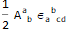

In [415]:
DualStar[A[ua, lb], {la, ub, lc, ld}]

A[ua, lb, ud] Epsilon[la, ub, ld, lc]
-------------------------------------
                  6
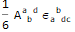

In [416]:
DualStar[A[ua, lb, ud], {la, ub, ld, lc}]

A[ua, lb, ud, uc] Epsilon[la, ub, ld, lc]
-----------------------------------------
                   24
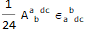

In [417]:
DualStar[A[ua, lb, ud, uc], {la, ub, ld, lc}]

A[ua, lb] Epsilon[la, ub, lc]
-----------------------------
              2
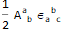

In [418]:
DualStar[A[ua, lb], {la, ub, lc}]

In [419]:
SetDimension[4]

In [420]:
DualStar[A[ua, lb], {la, ub, lc}]

`1` `2` `3` `4`: Invalid numbers of indices:  {la, ub, lc}  

A[ua, lb] Epsilon[la, ub, lc, ld]
---------------------------------
                2
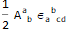

In [421]:
DualStar[A[ua, lb], {la, ub, lc, ld}]

In [422]:
ClearDimension[]

In [423]:
Tdefine[CA, "*-", Capital]

In [424]:
DualStar[CA[uA], {lA, lB}, Capital]

CA[uA] EpsilonCapital[lA, lB]

CA[uA, lB] EpsilonCapital[lA, uB, lC]
-------------------------------------
                  2
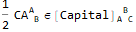

In [425]:
DualStar[CA[uA, lB], {lA, uB, lC}, Capital]

CA[uA, lD, lB] EpsilonCapital[lA, uD, uB, lC]
---------------------------------------------
                      6
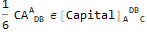

In [426]:
DualStar[CA[uA, lD, lB], {lA, uD, uB, lC}, Capital]

In [427]:
SetDimension[4]; SetSignature[2]

A[ld, ue, uf] Epsilon[ud, le, lf, la]
-------------------------------------
                  6
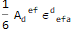

In [428]:
DualStar[A[ld, ue, uf], {ud, le, lf, la}]

A[lb, uc, ug] Epsilon[ua, ld, ue, uf] Epsilon[ub, lc, lg, la]
-------------------------------------------------------------
                              6
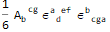

In [429]:
DualStar[%, {ua, ld, ue, uf}]

A[ld, ue, uf]   A[ld, uf, ue]   A[lb, uc, uf] Metricg[ld, lc] Metricg[ue, ub]
------------- - ------------- - --------------------------------------------- + 
      6               6                               6
 
    A[lb, uf, ug] Metricg[ld, lg] Metricg[ue, ub]
>   --------------------------------------------- + 
                          6
 
    A[lb, uc, ue] Metricg[ld, lc] Metricg[uf, ub]
>   --------------------------------------------- - 
                          6
 
    A[lb, ue, ug] Metricg[ld, lg] Metricg[uf, ub]
>   ---------------------------------------------
                          6
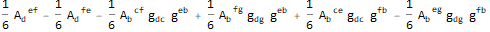

In [430]:
% /. EpsilonProductRule[]

A[ld, ue, uf]   A[uf, ld, la] Metricg[ue, ua]   A[ue, ld, la] Metricg[uf, ua]
------------- + ----------------------------- - -----------------------------
      3                       3                               3
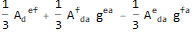

In [431]:
% // Tsimplify

A[ld, ue, uf]   A[ue, ld, uf]   A[uf, ld, ue]
------------- - ------------- + -------------
      3               3               3
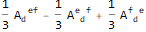

In [432]:
% // Absorbg

In [433]:
% // Tsimplify

A[ld, ue, uf]

In [434]:
ClearDimension[]; ClearSignature[]

### Check

In [435]:
DualStar[CA[uA, uB], {lA}]

`1` `2` `3` `4`: Invalid numbers of indices:  {lA}  

In [436]:
DualStar[A[ua, ub], {ua, lb}]

`1` `2` `3` `4`: Ill-formed indices:  {ua, lb}  

In [437]:
SetDimension[3]

In [438]:
DualStar[A[ua, lb, uc, ud], {la, ub, lc}]

`1` `2` `3` `4`: Invalid numbers of free indices:  {ua, lb, uc, ud}  

In [439]:
DualStar[A[ua, ub], {la, lb, lc, ld}]

`1` `2` `3` `4`: Invalid numbers of indices:  {la, lb, lc, ld}  

In [440]:
ClearDimension[]